# Exploratory SNA, chapter 5


This notebook provides a Python transcription of the analyses that are presented in Chapter 5 "Affiliations" of the book: Wouter de Nooy / Andrej Mrvar / Vladimir Batagelj, _Exploratory Social Network Analysis with Pajek_, Third edition, Cambridge: Cambridge University Press, 2018. 


It reuses the same data about directors and co-directors in different firms stemming from an "historical example: the corporate interlocks in Scotland in the beginning of the twentieth century (1904–5)". 

Data import demands some workarounds (see below)


[10 Mai 2025] At the moment the notebook covers only up to par. 5.4 included.

...



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches

import numpy as np
import scipy.stats as stats
import pprint as pprint

In [2]:
# https://networkx.org/documentation/stable/install.html
import networkx as nx

from networkx.algorithms import bipartite

#### https://ipycytoscape.readthedocs.io/en/latest/installing.html
# import ipycytoscape as cy

In [3]:
import sys
from importlib import reload

# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')

In [4]:
import network_analysis_functions as naf

In [5]:
print(reload(naf))

<module 'network_analysis_functions' from '/home/francesco/kDrive/python_notebooks/sciences_historiques_numeriques/histoire_numerique_methodes/analyse_reseaux/pajek_book/../network_analysis_functions.py'>


In [6]:
### Open the Pajek file

## WARNING
# The number companies, 108, must deleted before importing of the file
# The same for the "*Arcs" clause, there are only "*Edges, it's and undirected graph"

f = '../data/Chapter5/Scotland_modified.net'
G = nx.read_pajek(f)

## MultiDiGraph: Directed graphs with self loops and parallel edges
# https://networkx.org/documentation/stable/reference/classes/multidigraph.html#networkx.MultiDiGraph
print(type(G))

<class 'networkx.classes.multigraph.MultiGraph'>


In [7]:
### Use the custom function to inspect the graph properties
naf.basic_graph_properties(G)

{'is_multigraph': True,
 'is_directed': False,
 'number_of_nodes': 244,
 'number_of_edges': 358,
 '------': '------',
 'is connected': False,
 'components': 20,
 'density': 0.012075828104972004}


We notice that the network has been transformed into a multigraph during the import.

There are also a number of components. We will first add some attributes to the nodes, then check the components.


### Inspect and update nodes and edges

In [8]:
### Inspect properties of nodes and edges
print(list(G.nodes.data())[:5])
print('-')
## Inspect edges
print(list(G.edges.data())[-5:])

[('north british railway', {'id': '1', 'x': 0.0, 'y': 0.0, 'shape': '0.5000'}), ('caledonian railway', {'id': '2', 'x': 0.0, 'y': 0.0, 'shape': '0.5000'}), ('glasgow & south western railway', {'id': '3', 'x': 0.0, 'y': 0.0, 'shape': '0.5000'}), ('j. & p. coats', {'id': '4', 'x': 0.0, 'y': 0.0, 'shape': '0.5000'}), ('great north of scotland railway', {'id': '5', 'x': 0.0, 'y': 0.0, 'shape': '0.5000'})]
-
[('edinburgh american land mortgage', 'duncan, a.r.', {'weight': 1.0}), ('transvaal proprietary', 'hilliard, j.b.', {'weight': 1.0}), ('reversionary association', 'aitken, t.', {'weight': 1.0}), ('reversionary association', 'watt, a.', {'weight': 1.0}), ('reversionary association', 'campbell, j.', {'weight': 1.0})]


In [9]:
### Remove the attributes listed below from all nodes
attrs_to_remove = ['x', 'y', 'shape']

# Custom funtion in local namespace naf
naf.remove_node_attributes(G, attrs_to_remove)

l_nd = list(G.nodes.data())
print(l_nd[:5])

[('north british railway', {'id': '1'}), ('caledonian railway', {'id': '2'}), ('glasgow & south western railway', {'id': '3'}), ('j. & p. coats', {'id': '4'}), ('great north of scotland railway', {'id': '5'})]


#### Add identifiers as names and the bipartite attribute


Exploratory SNA, p.121:

* Affiliation networks consist of at least two sets of vertices
such that affiliations connect vertices from different sets only.
* In the original data, nodes 1 to 108 are companies, the rest persons.


In [10]:
l = dict([
            (n[0], {'label':n[0], 
                   'bipartite': (0 if int(n[1]['id']) < 109 else 1) 
                  }) for n in l_nd])
# Print first 100 characters of the dictionary
print(str(l)[:100])

{'north british railway': {'label': 'north british railway', 'bipartite': 0}, 'caledonian railway': 


In [11]:
## Add attributes to nodes
nx.set_node_attributes(G, l)
pprint.pprint(list(G.nodes.data())[:3])

[('north british railway',
  {'bipartite': 0, 'id': '1', 'label': 'north british railway'}),
 ('caledonian railway',
  {'bipartite': 0, 'id': '2', 'label': 'caledonian railway'}),
 ('glasgow & south western railway',
  {'bipartite': 0, 'id': '3', 'label': 'glasgow & south western railway'})]


#### Relabel nodes

Use the 'id' attribute for the node and add the node name as a label.

You will use the old 'name' to identify nodes then replace it with 'id'.

In [12]:
### Prepare the attribute
dd = dict([[k, v['id']] for k, v in G.nodes.data()])

# Print first 100 characters of the dictionary
print(str(dd)[:100])

{'north british railway': '1', 'caledonian railway': '2', 'glasgow & south western railway': '3', 'j


In [13]:
### Relabel nodes
## Set a new identifier
# https://networkx.org/documentation/stable/reference/generated/networkx.relabel.relabel_nodes.html

G=nx.relabel_nodes(G, dd, copy=True)

### Remove the 'id' attribute 
attrs_to_remove = ['id']
naf.remove_node_attributes(G, attrs_to_remove)


pprint.pprint(list(G.nodes(data=True))[:3])

[('1', {'bipartite': 0, 'label': 'north british railway'}),
 ('2', {'bipartite': 0, 'label': 'caledonian railway'}),
 ('3', {'bipartite': 0, 'label': 'glasgow & south western railway'})]


### Bipartite graph properties

In [14]:
### Documentation
#  https://networkx.org/documentation/stable/reference/algorithms/bipartite.html
print('Is bipartite: ', bipartite.is_bipartite(G))
print('---')
naf.basic_graph_properties(G)

Is bipartite:  True
---
{'is_multigraph': True,
 'is_directed': False,
 'number_of_nodes': 244,
 'number_of_edges': 358,
 '------': '------',
 'is connected': False,
 'components': 20,
 'density': 0.012075828104972004}


### Graph components


Split and inspect graph components


In [15]:
### Create a list of graphs, one per component
## Connected components
# https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.components.connected_components.html
try:
    S = [G.subgraph(c).copy() for c in nx.connected_components(G)]

    ### i is the component index in the list S of graphs , len(s.nodes) is the nomber of nodes
    ln = sorted([[i,len(g.nodes)] for i,g in enumerate(S)], key = lambda row: row[1], reverse=True)
    print(ln[:5])


except Exception as e:
    print(e)


[[0, 217], [1, 4], [2, 4], [6, 3], [3, 1]]


In [16]:
s_ln = pd.Series([e[1] for e in ln])
print(s_ln.describe()) 

### Distribution of number of nodes
print('\n\
Distribution of number of nodes:')
l = [print('Nodes in graph: ', e[0],
           ', number of graphs: ', e[1]) for e in s_ln.groupby(by=s_ln).size().items()]



count     20.000000
mean      12.200000
std       48.215088
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max      217.000000
dtype: float64

Distribution of number of nodes:
Nodes in graph:  1 , number of graphs:  16
Nodes in graph:  3 , number of graphs:  1
Nodes in graph:  4 , number of graphs:  2
Nodes in graph:  217 , number of graphs:  1


We will consider only the largest component

In [17]:
lG = S[0]
naf.basic_graph_properties(lG)

{'is_multigraph': True,
 'is_directed': False,
 'number_of_nodes': 217,
 'number_of_edges': 348,
 '------': '------',
 'is connected': True,
 'components': 1,
 'density': 0.014848950332821301}


In [18]:
### Identify the two node sets
# https://networkx.org/documentation/stable/reference/algorithms/bipartite.html

companies,persons = bipartite.sets(lG)
print('Companies: ', list(companies)[:3])
print('Persons: ', list(persons)[:3])

Companies:  ['35', '83', '81']
Persons:  ['137', '238', '170']


In [19]:
### Bipartite graph density
# The density is higher because the number of possible 
# relations is lower in a bipartite graph
bipartite.density(G, companies)

0.026346776567559613

In [20]:
### Specific function, splits nodes with degrees
# into two distinct sets

dP,dC = bipartite.degrees(lG,companies)
print(sorted(dC, key=lambda x: int(x[0])))

[('1', 8), ('2', 13), ('3', 5), ('4', 4), ('6', 6), ('7', 3), ('8', 8), ('9', 2), ('10', 2), ('11', 3), ('12', 1), ('14', 3), ('15', 3), ('16', 3), ('17', 5), ('19', 8), ('20', 1), ('21', 1), ('23', 1), ('24', 8), ('26', 8), ('27', 2), ('28', 4), ('29', 5), ('30', 4), ('31', 1), ('33', 4), ('35', 1), ('36', 1), ('38', 3), ('39', 4), ('45', 3), ('46', 4), ('48', 1), ('50', 1), ('51', 4), ('53', 5), ('55', 2), ('56', 1), ('58', 3), ('59', 3), ('61', 3), ('62', 1), ('63', 1), ('64', 1), ('65', 8), ('66', 9), ('67', 8), ('68', 9), ('69', 10), ('70', 4), ('71', 6), ('73', 12), ('74', 6), ('75', 5), ('76', 9), ('77', 3), ('78', 5), ('79', 2), ('80', 4), ('81', 4), ('82', 5), ('83', 4), ('84', 4), ('85', 5), ('86', 2), ('87', 4), ('88', 4), ('89', 6), ('90', 3), ('91', 3), ('92', 1), ('93', 4), ('94', 1), ('95', 4), ('96', 4), ('98', 1), ('99', 5), ('100', 2), ('101', 3), ('102', 5), ('103', 4), ('104', 4), ('105', 4), ('106', 1), ('108', 3)]


In [21]:
### Same degree values, but just one set
dA = lG.degree()

print(sorted(dA, key=lambda x: int(x[0])))

[('1', 8), ('2', 13), ('3', 5), ('4', 4), ('6', 6), ('7', 3), ('8', 8), ('9', 2), ('10', 2), ('11', 3), ('12', 1), ('14', 3), ('15', 3), ('16', 3), ('17', 5), ('19', 8), ('20', 1), ('21', 1), ('23', 1), ('24', 8), ('26', 8), ('27', 2), ('28', 4), ('29', 5), ('30', 4), ('31', 1), ('33', 4), ('35', 1), ('36', 1), ('38', 3), ('39', 4), ('45', 3), ('46', 4), ('48', 1), ('50', 1), ('51', 4), ('53', 5), ('55', 2), ('56', 1), ('58', 3), ('59', 3), ('61', 3), ('62', 1), ('63', 1), ('64', 1), ('65', 8), ('66', 9), ('67', 8), ('68', 9), ('69', 10), ('70', 4), ('71', 6), ('73', 12), ('74', 6), ('75', 5), ('76', 9), ('77', 3), ('78', 5), ('79', 2), ('80', 4), ('81', 4), ('82', 5), ('83', 4), ('84', 4), ('85', 5), ('86', 2), ('87', 4), ('88', 4), ('89', 6), ('90', 3), ('91', 3), ('92', 1), ('93', 4), ('94', 1), ('95', 4), ('96', 4), ('98', 1), ('99', 5), ('100', 2), ('101', 3), ('102', 5), ('103', 4), ('104', 4), ('105', 4), ('106', 1), ('108', 3), ('109', 3), ('110', 3), ('111', 5), ('112', 4), ('

In [22]:
### Print network


node_colors=['blue' if n[1]['bipartite'] == 0 else 'red' for n in lG.nodes.data()]
node_size=[(d[1]-2+0.2)*50 for d in lG.degree()]
node_labels=dict([(n[0], ('-'.join((n[1]['label']).split(' ')[:5]) if n[1]['bipartite'] == 0 else '')) for n in lG.nodes.data()])


plt.figure(figsize = (12,12))

#pos = nx.kamada_kawai_layout(U)

k=0.8
pos=nx.spring_layout(lG, k=k)

nx.draw_networkx_nodes(lG, pos, node_size=node_size, node_color=node_colors, alpha=0.4)
nx.draw_networkx_labels(lG, pos, labels=node_labels, font_size=5)

## no need to draw edges to see the structure of the graph
#nx.draw_networkx_edges(lG, pos,  width=0.5, alpha=0.2)

plt.title('Larger component with both nodes types (size proportional to degree)')

### cf. SVG picture
plt.savefig('images/bipartite_scotland.svg')
plt.close()

/home/francesco/miniconda3/envs/py311_data_analysis/lib/python3.11/site-packages/matplotlib/collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


## Treat the multigraph issue

In [23]:
naf.basic_graph_properties(lG)

{'is_multigraph': True,
 'is_directed': False,
 'number_of_nodes': 217,
 'number_of_edges': 348,
 '------': '------',
 'is connected': True,
 'components': 1,
 'density': 0.014848950332821301}


In [24]:
## Inspect edges
print(list(lG.edges.data())[-5:])

[('105', '243', {'weight': 1.0}), ('106', '236', {'weight': 1.0}), ('108', '167', {'weight': 1.0}), ('108', '179', {'weight': 1.0}), ('108', '244', {'weight': 1.0})]


In [25]:
### Test if multigraph has loops

## Result: no loop

print(list(nx.nodes_with_selfloops(lG)))

[]


#### Treat possible multiple edges

In [26]:
## For each identical edge
# (same source and target nodes)
# adds 1 to weight

SG = nx.Graph()
for u,v,data in lG.edges(data=True):
    w = data['weight'] if 'weight' in data else 1.0
    if SG.has_edge(u,v):
        SG[u][v]['weight'] += w
    else:
        SG.add_edge(u, v, weight=w)

print(SG.edges(data=True))

[('1', '109', {'weight': 1.0}), ('1', '110', {'weight': 1.0}), ('1', '111', {'weight': 1.0}), ('1', '112', {'weight': 1.0}), ('1', '113', {'weight': 1.0}), ('1', '114', {'weight': 1.0}), ('1', '115', {'weight': 1.0}), ('1', '116', {'weight': 1.0}), ('109', '7', {'weight': 1.0}), ('109', '73', {'weight': 1.0}), ('110', '28', {'weight': 1.0}), ('110', '68', {'weight': 1.0}), ('111', '63', {'weight': 1.0}), ('111', '93', {'weight': 1.0}), ('111', '103', {'weight': 1.0}), ('111', '104', {'weight': 1.0}), ('112', '7', {'weight': 1.0}), ('112', '23', {'weight': 1.0}), ('112', '50', {'weight': 1.0}), ('113', '16', {'weight': 1.0}), ('114', '53', {'weight': 1.0}), ('115', '16', {'weight': 1.0}), ('116', '21', {'weight': 1.0}), ('116', '81', {'weight': 1.0}), ('2', '117', {'weight': 1.0}), ('2', '118', {'weight': 1.0}), ('2', '119', {'weight': 1.0}), ('2', '120', {'weight': 1.0}), ('2', '121', {'weight': 1.0}), ('2', '122', {'weight': 1.0}), ('2', '123', {'weight': 1.0}), ('2', '124', {'weight'

In [27]:
### List of edges with 'weight' larger than 1
print([e for e in SG.edges.data() if e[2]['weight']> 1])

# No such edge: in fact, the graph is simple, no loops, no multiple edges

[]


In [28]:
### Print weight distribution
s = pd.Series([e[2]['weight'] for e in SG.edges.data()])
print(s.groupby(by=s).size())

1.0    348
dtype: int64


In [29]:
### Remove the attributes listed below from all nodes
attrs_to_remove = ['weight']


for n1, n2, d in lG.edges(data=True):
    for att in attrs_to_remove:
        d.pop(att, None)

l_nd = list(lG.edges.data())
print(l_nd[:5])

[('1', '109', {}), ('1', '110', {}), ('1', '111', {}), ('1', '112', {}), ('1', '113', {})]


## Project the graph on companies

* First add attributes to the nodes in the simple graph
* Then project graph

In [30]:
### Add attributes to the nodes in the simple graph

print(str(lG.nodes.data())[:300])
nx.set_node_attributes(SG, dict(lG.nodes.data()))


[('1', {'label': 'north british railway', 'bipartite': 0}), ('2', {'label': 'caledonian railway', 'bipartite': 0}), ('3', {'label': 'glasgow & south western railway', 'bipartite': 0}), ('4', {'label': 'j. & p. coats', 'bipartite': 0}), ('6', {'label': 'highland railway', 'bipartite': 0}), ('7', {'la


In [31]:
### First project the graph
## Documentation:
# https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.bipartite.projection.weighted_projected_graph.html#networkx.algorithms.bipartite.projection.weighted_projected_graph

"""
Parameter 'ratio': Bool (default=False)
If True, edge weight is the ratio between 
actual shared neighbors and maximum possible 
shared neighbors (i.e., the size of the other node set). 
If False, edges weight is the number of shared neighbors.
"""

projSG = bipartite.weighted_projected_graph(SG, companies, ratio=False)

### add weight to list
lwi = dict([((e[0], e[1]), e[2]['weight']) for e in projSG.edges.data()])

### Then reproject the graph but with ratio=True
projSG = bipartite.weighted_projected_graph(SG, companies, ratio=True)

### Then add the integer value
nx.set_edge_attributes(projSG, lwi, 'integer_weight')




print(list(projSG.nodes.data())[:3])
print(list(projSG.edges.data())[:3])

print('---')
naf.basic_graph_properties(projSG)

[('35', {'label': 'allan line steamships', 'bipartite': 0}), ('83', {'label': 'city of glasgow life ass.', 'bipartite': 0}), ('81', {'label': 'scottish union & national ins.', 'bipartite': 0})]
[('35', '2', {'weight': 0.007633587786259542, 'integer_weight': 1}), ('35', '71', {'weight': 0.007633587786259542, 'integer_weight': 1}), ('83', '16', {'weight': 0.007633587786259542, 'integer_weight': 1})]
---
{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 86,
 'number_of_edges': 273,
 '------': '------',
 'is connected': True,
 'components': 1,
 'density': 0.0746922024623803}


count    273.000000
mean       0.010290
std        0.008757
min        0.007634
25%        0.007634
50%        0.007634
75%        0.007634
max        0.061069
dtype: float64


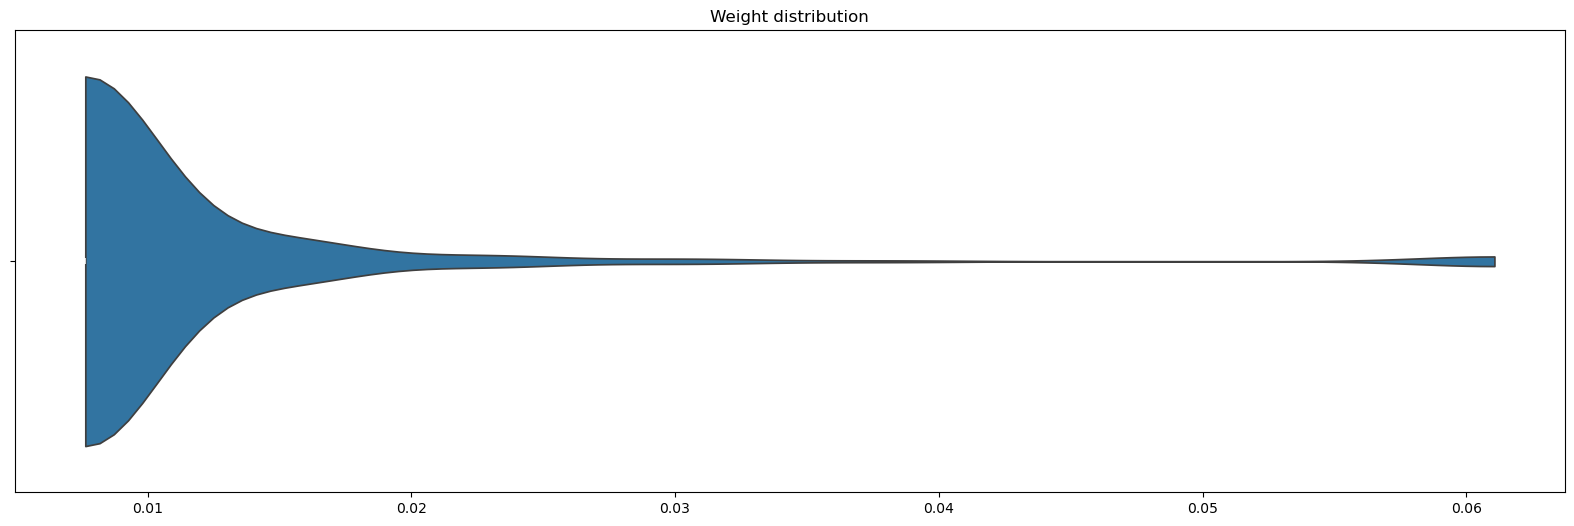

In [32]:
### distribution of normalized weight
lw = [e[2]['weight'] for e in projSG.edges.data()]

naf.describe_violinplot(lw, 'Weight distribution')

count    273.000000
mean       1.347985
std        1.147153
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        8.000000
dtype: float64


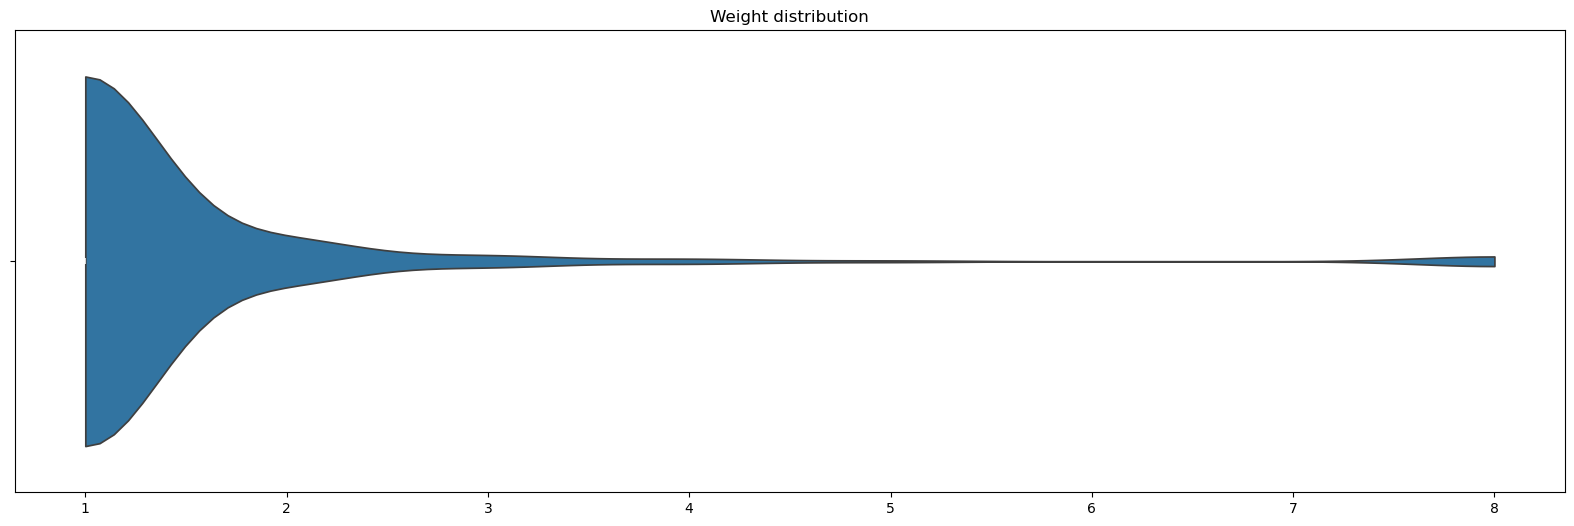

In [33]:
### Distribution of integer weight
lw = [e[2]['integer_weight'] for e in projSG.edges.data()]

naf.describe_violinplot(lw, 'Weight distribution')

In [34]:
print(list(projSG.nodes.data())[:3])
print(list(projSG.edges.data())[:3])

[('35', {'label': 'allan line steamships', 'bipartite': 0}), ('83', {'label': 'city of glasgow life ass.', 'bipartite': 0}), ('81', {'label': 'scottish union & national ins.', 'bipartite': 0})]
[('35', '2', {'weight': 0.007633587786259542, 'integer_weight': 1}), ('35', '71', {'weight': 0.007633587786259542, 'integer_weight': 1}), ('83', '16', {'weight': 0.007633587786259542, 'integer_weight': 1})]


### Plot the graph with centralities

#### Eigenvector

count    86.00000000000000000000
mean      0.02694714567761263141
std       0.10502387488932550530
min       0.00000053393592556724
25%       0.00001382393642569029
50%       0.00003751008138064080
75%       0.00020240903541211605
max       0.49350325145174200880
dtype: object


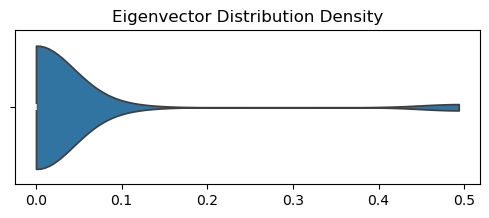

In [35]:
le = list(nx.eigenvector_centrality(projSG, 
                        max_iter=200, weight='weight').items())
### Plot eigenvector density distribution 
eigenvector_s = pd.Series([e[1] for e in le])
stats = eigenvector_s.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

# Plot the distribution of eigenvector density

plt.figure(figsize=(6, 2))
p = sns.violinplot(data=eigenvector_s, orient='h', cut=0)
plt.title('Eigenvector Distribution Density')
plt.show()


In [36]:
nx.set_node_attributes(projSG, dict(le), 'eigenvector')
print(list(projSG.nodes.data())[:3])

[('35', {'label': 'allan line steamships', 'bipartite': 0, 'eigenvector': 2.7475099319254007e-05}), ('83', {'label': 'city of glasgow life ass.', 'bipartite': 0, 'eigenvector': 1.6445432045263717e-05}), ('81', {'label': 'scottish union & national ins.', 'bipartite': 0, 'eigenvector': 2.049847081324225e-05})]


count    86.00000000000000000000
mean      0.02694714567761263141
std       0.10502387488932550530
min       0.00000053393592556724
25%       0.00001382393642569029
50%       0.00003751008138064080
75%       0.00020240903541211605
max       0.49350325145174200880
dtype: object


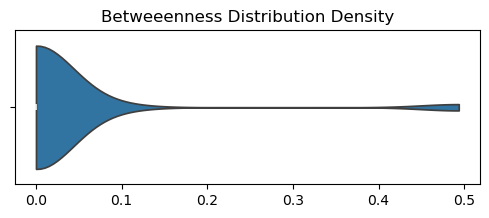

In [37]:
lb = list(nx.betweenness_centrality(G, weight='weight').items())
### Plot betweenness density distribution 
betweenness_s = pd.Series([e[1] for e in le])
stats = betweenness_s.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

# Plot the distribution of eigenvector density

plt.figure(figsize=(6, 2))
p = sns.violinplot(data=betweenness_s, orient='h', cut=0)
plt.title('Betweeenness Distribution Density')
plt.show()



In [38]:
nx.set_node_attributes(projSG, dict(lb), 'betweenness')
print(list(projSG.nodes.data())[:3])

[('35', {'label': 'allan line steamships', 'bipartite': 0, 'eigenvector': 2.7475099319254007e-05, 'betweenness': 0.0}), ('83', {'label': 'city of glasgow life ass.', 'bipartite': 0, 'eigenvector': 1.6445432045263717e-05, 'betweenness': 0.012467031987714684}), ('81', {'label': 'scottish union & national ins.', 'bipartite': 0, 'eigenvector': 2.049847081324225e-05, 'betweenness': 0.014285759721392054})]


#### Define normalized degree

In [39]:
lc = sorted(list(dC), key=lambda x: int(x[0]))
print(lc)


[('1', 8), ('2', 13), ('3', 5), ('4', 4), ('6', 6), ('7', 3), ('8', 8), ('9', 2), ('10', 2), ('11', 3), ('12', 1), ('14', 3), ('15', 3), ('16', 3), ('17', 5), ('19', 8), ('20', 1), ('21', 1), ('23', 1), ('24', 8), ('26', 8), ('27', 2), ('28', 4), ('29', 5), ('30', 4), ('31', 1), ('33', 4), ('35', 1), ('36', 1), ('38', 3), ('39', 4), ('45', 3), ('46', 4), ('48', 1), ('50', 1), ('51', 4), ('53', 5), ('55', 2), ('56', 1), ('58', 3), ('59', 3), ('61', 3), ('62', 1), ('63', 1), ('64', 1), ('65', 8), ('66', 9), ('67', 8), ('68', 9), ('69', 10), ('70', 4), ('71', 6), ('73', 12), ('74', 6), ('75', 5), ('76', 9), ('77', 3), ('78', 5), ('79', 2), ('80', 4), ('81', 4), ('82', 5), ('83', 4), ('84', 4), ('85', 5), ('86', 2), ('87', 4), ('88', 4), ('89', 6), ('90', 3), ('91', 3), ('92', 1), ('93', 4), ('94', 1), ('95', 4), ('96', 4), ('98', 1), ('99', 5), ('100', 2), ('101', 3), ('102', 5), ('103', 4), ('104', 4), ('105', 4), ('106', 1), ('108', 3)]


In [40]:
ld = sorted(list(projSG.degree()), key=lambda x: int(x[0]))
print(ld)
      

[('1', 14), ('2', 26), ('3', 7), ('4', 11), ('6', 10), ('7', 5), ('8', 7), ('9', 2), ('10', 2), ('11', 7), ('12', 2), ('14', 2), ('15', 8), ('16', 3), ('17', 13), ('19', 7), ('20', 2), ('21', 2), ('23', 3), ('24', 7), ('26', 7), ('27', 8), ('28', 8), ('29', 11), ('30', 10), ('31', 2), ('33', 12), ('35', 2), ('36', 2), ('38', 2), ('39', 3), ('45', 4), ('46', 4), ('48', 4), ('50', 3), ('51', 5), ('53', 14), ('55', 2), ('56', 1), ('58', 10), ('59', 5), ('61', 5), ('62', 1), ('63', 4), ('64', 2), ('65', 10), ('66', 11), ('67', 11), ('68', 9), ('69', 12), ('70', 4), ('71', 17), ('73', 14), ('74', 5), ('75', 6), ('76', 18), ('77', 3), ('78', 5), ('79', 5), ('80', 2), ('81', 5), ('82', 8), ('83', 5), ('84', 6), ('85', 9), ('86', 5), ('87', 6), ('88', 9), ('89', 8), ('90', 6), ('91', 4), ('92', 1), ('93', 6), ('94', 1), ('95', 9), ('96', 8), ('98', 3), ('99', 6), ('100', 5), ('101', 5), ('102', 7), ('103', 6), ('104', 6), ('105', 4), ('106', 1), ('108', 4)]


In [41]:
z = zip(lc,ld)
zz = [(e[0][0],e[0][1], e[1][1]) 
            for e in z]
df_zz = pd.DataFrame(zz, columns=['name', 'n_members', 'degree'] )
#df_zz.set_index('name', inplace=True)
df_zz['norm_degree'] = df_zz.apply(lambda x: x.degree/x.n_members, axis=1)
pprint.pprint(df_zz)

   name  n_members  degree  norm_degree
0     1          8      14     1.750000
1     2         13      26     2.000000
2     3          5       7     1.400000
3     4          4      11     2.750000
4     6          6      10     1.666667
..  ...        ...     ...          ...
81  103          4       6     1.500000
82  104          4       6     1.500000
83  105          4       4     1.000000
84  106          1       1     1.000000
85  108          3       4     1.333333

[86 rows x 4 columns]


count    86.00000000000000000000
mean      1.71411498708010334724
std       0.79663989060802520292
min       0.50000000000000000000
25%       1.00000000000000000000
50%       1.50000000000000000000
75%       2.00000000000000000000
max       4.00000000000000000000
Name: norm_degree, dtype: object


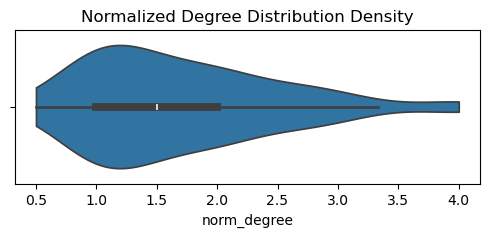

In [42]:
### Plot normalized degree  density distribution 
stats = df_zz.norm_degree.describe()

# Format decimal values
stats = stats.apply(lambda x: format(x, '.20f'))

print(stats)

# Plot the distribution of eigenvector density

plt.figure(figsize=(6, 2))
p = sns.violinplot(data=df_zz.norm_degree, orient='h', cut=0)
plt.title('Normalized Degree Distribution Density')
plt.show()

#### Add to nodes and create dataframe

In [43]:
### Prepare data to add to nodes
ln = dict([(e['name'],
     {'members':e['n_members'], 'degree':e['degree'], 'norm_degree':e['norm_degree']}
     ) for e in df_zz.to_dict(orient='records')])
# print(str(ln)[:200])


In [44]:
## Add attributes
nx.set_node_attributes(projSG, ln)
pprint.pprint(list(projSG.nodes.data())[:2])

[('35',
  {'betweenness': 0.0,
   'bipartite': 0,
   'degree': 2,
   'eigenvector': 2.7475099319254007e-05,
   'label': 'allan line steamships',
   'members': 1,
   'norm_degree': 2.0}),
 ('83',
  {'betweenness': 0.012467031987714684,
   'bipartite': 0,
   'degree': 5,
   'eigenvector': 1.6445432045263717e-05,
   'label': 'city of glasgow life ass.',
   'members': 4,
   'norm_degree': 1.25})]


#### Add industrial categories



Exploratory SNA, p. 129

domestic products [class 5], railways
[class 2], electricity [class 4], and investments [class 8]) and one larger
island mainly connected by financial institutions (banks [class 6], insurance companies [class 7], and investment banks [class 8])

In [45]:
### List of nodes' identifiers
nodes = sorted(list(projSG.nodes.keys()), key=lambda x: int(x))
print(nodes[:3])

['1', '2', '3']


In [46]:
### Open the clusters file and zip it together with the 
# nodes' identifiers (they are in the same ordre and samel length)
f='../data/Chapter5/Industrial_categories.clu'
cluster= pd.read_csv(f)
print(cluster.head(10))

   *Vertices   108
0                2
1                2
2                2
3                5
4                2
5                2
6                2
7                5
8                5
9                1


In [47]:

l = list(cluster["*Vertices   108"])
print(l[:3])
ln = list(zip(nodes,l))
print(ln[:10])


[2, 2, 2]
[('1', 2), ('2', 2), ('3', 2), ('4', 5), ('6', 2), ('7', 2), ('8', 2), ('9', 5), ('10', 5), ('11', 1)]


In [48]:
### Prepare the industrial category clusters to add to the nodes
categories = dict([(d[0], {'categories': d[1]}) for d in ln])

### Add the industrial category clusters to the nodes
nx.set_node_attributes(projSG, categories)

print(list(projSG.nodes.data())[:3])

[('35', {'label': 'allan line steamships', 'bipartite': 0, 'eigenvector': 2.7475099319254007e-05, 'betweenness': 0.0, 'members': 1, 'degree': 2, 'norm_degree': 2.0, 'categories': 1}), ('83', {'label': 'city of glasgow life ass.', 'bipartite': 0, 'eigenvector': 1.6445432045263717e-05, 'betweenness': 0.012467031987714684, 'members': 4, 'degree': 5, 'norm_degree': 1.25, 'categories': 5}), ('81', {'label': 'scottish union & national ins.', 'bipartite': 0, 'eigenvector': 2.049847081324225e-05, 'betweenness': 0.014285759721392054, 'members': 4, 'degree': 5, 'norm_degree': 1.25, 'categories': 5})]


#### Add categories to labels

In [49]:
print([(n[0], {'label':str(n[1]['categories'])+'/'+ n[0]+'—'+n[1]['label']}) for n in projSG.nodes.data()])

[('35', {'label': '1/35—allan line steamships'}), ('83', {'label': '5/83—city of glasgow life ass.'}), ('81', {'label': '5/81—scottish union & national ins.'}), ('59', {'label': '3/59—scottish waggon'}), ('84', {'label': '1/84—caledonian ass.'}), ('98', {'label': '7/98—oregon mortgage'}), ('24', {'label': '5/24—anglo-american direct tea trading'}), ('65', {'label': '2/65—bank of scotland'}), ('99', {'label': '7/99—scottish investment trust'}), ('61', {'label': '4/61—robertson, sanderson'}), ('71', {'label': '5/71—clydesdale bank'}), ('16', {'label': '3/16—glasgow district subway'}), ('103', {'label': '7/103—second scottish american trust'}), ('73', {'label': '4/73—scottish widows fund life ass.'}), ('74', {'label': '5/74—north british & mercantile ins.'}), ('2', {'label': '2/2—caledonian railway'}), ('63', {'label': '3/63—victoria jute'}), ('23', {'label': '5/23—west highland railway'}), ('1', {'label': '2/1—north british railway'}), ('9', {'label': '5/9—linen thread'}), ('101', {'labe

In [50]:
### Prepare the industrial category clusters to add to the nodes
labels = dict([(n[0], {'label':str(n[1]['categories'])+'/'+ n[0]+'—'+n[1]['label']}) for n in projSG.nodes.data()])

### Add the industrial category clusters to the nodes
nx.set_node_attributes(projSG, labels)

print(list(projSG.nodes.data())[:3])

[('35', {'label': '1/35—allan line steamships', 'bipartite': 0, 'eigenvector': 2.7475099319254007e-05, 'betweenness': 0.0, 'members': 1, 'degree': 2, 'norm_degree': 2.0, 'categories': 1}), ('83', {'label': '5/83—city of glasgow life ass.', 'bipartite': 0, 'eigenvector': 1.6445432045263717e-05, 'betweenness': 0.012467031987714684, 'members': 4, 'degree': 5, 'norm_degree': 1.25, 'categories': 5}), ('81', {'label': '5/81—scottish union & national ins.', 'bipartite': 0, 'eigenvector': 2.049847081324225e-05, 'betweenness': 0.014285759721392054, 'members': 4, 'degree': 5, 'norm_degree': 1.25, 'categories': 5})]


In [51]:
### Open the capital file and zip it together with the 
# nodes' identifiers (they are in the same ordre and samel length)
f='../data/Chapter5/Capital.vec'
vec= pd.read_csv(f)
print(vec.head(10))

   *Vertices   108
0            47236
1            42899
2            14204
3            10000
4             4979
5             4653
6             2325
7             2000
8             1991
9             1850


In [52]:

l = list(vec["*Vertices   108"])
print(l[:3])
ln = list(zip(nodes,l))
print(ln[:10])


[47236, 42899, 14204]
[('1', 47236), ('2', 42899), ('3', 14204), ('4', 10000), ('6', 4979), ('7', 4653), ('8', 2325), ('9', 2000), ('10', 1991), ('11', 1850)]


In [53]:
### Prepare the capital clusters to add to the nodes
capital = dict([(d[0], {'capital': d[1]}) for d in ln])

### Add the family clusters to the nodes
nx.set_node_attributes(projSG, capital)

print(list(projSG.nodes.data())[:3])

[('35', {'label': '1/35—allan line steamships', 'bipartite': 0, 'eigenvector': 2.7475099319254007e-05, 'betweenness': 0.0, 'members': 1, 'degree': 2, 'norm_degree': 2.0, 'categories': 1, 'capital': 831}), ('83', {'label': '5/83—city of glasgow life ass.', 'bipartite': 0, 'eigenvector': 1.6445432045263717e-05, 'betweenness': 0.012467031987714684, 'members': 4, 'degree': 5, 'norm_degree': 1.25, 'categories': 5, 'capital': 350}), ('81', {'label': '5/81—scottish union & national ins.', 'bipartite': 0, 'eigenvector': 2.049847081324225e-05, 'betweenness': 0.014285759721392054, 'members': 4, 'degree': 5, 'norm_degree': 1.25, 'categories': 5, 'capital': 350})]


In [54]:
### Export node attributes to dataframe
nodes_data ={node: projSG.nodes[node] for node in projSG.nodes}
nodes_df = pd.DataFrame(nodes_data).T
nodes_df.reset_index(inplace=True)
nodes_df.columns = ['id', 'label', 'bipartite', 'eigenvector','betweenness',  
       'members', 'degree', 'norm_degree', 'categories','capital']

nodes_df.head(2)

,id,label,bipartite,eigenvector,betweenness,members,degree,norm_degree,categories,capital
0,35,1/35—allan line steamships,0,0.000027,0.0,1,2,2.0,1,831
1,83,5/83—city of glasgow life ass.,0,0.000016,0.012467,4,5,1.25,5,350


In [55]:
nodes_df[nodes_df.norm_degree > 2]\
   .sort_values(by='norm_degree', ascending=False)

,id,label,bipartite,eigenvector,betweenness,members,degree,norm_degree,categories,capital
16,63,3/63—victoria jute,0,0.000041,0.0,1,4,4.0,3,550
64,48,1/48—clan line steamers,0,0.08008,0.0,1,4,4.0,1,660
46,27,4/27—coltness iron,0,0.000092,0.001069,2,8,4.0,4,934
75,58,1/58—lothian coal,0,0.000083,0.034421,3,10,3.333333,1,600
5,98,7/98—oregon mortgage,0,0.000002,0.0,1,3,3.0,7,5399
44,33,3/33—irrawaddy flotilla,0,0.000341,0.060258,4,12,3.0,3,850
79,50,3/50—wemyss collieries trust,0,0.00001,0.0,1,3,3.0,3,606
17,23,5/23—west highland railway,0,0.00001,0.0,1,3,3.0,5,1000
10,71,5/71—clydesdale bank,0,0.000158,0.048321,6,17,2.833333,5,490
49,53,5/53—young's paraffin ligth & mineral oil,0,0.00014,0.036797,5,14,2.8,5,600


In [56]:
nodes_df[nodes_df.betweenness > 0.05]\
   .sort_values(by='betweenness', ascending=False)

,id,label,bipartite,eigenvector,betweenness,members,degree,norm_degree,categories,capital
15,2,2/2—caledonian railway,0,0.000397,0.166088,13,26,2.0,2,42899
29,76,3/76—standard life ass.,0,0.000117,0.108067,9,18,2.0,3,400
13,73,4/73—scottish widows fund life ass.,0,0.000084,0.107025,12,14,1.166667,4,453
31,6,2/6—highland railway,0,0.003373,0.08546,6,10,1.666667,2,4979
73,28,2/28—fife coal,0,0.003331,0.084795,4,8,2.0,2,929
18,1,2/1—north british railway,0,0.000196,0.071056,8,14,1.75,2,47236
53,67,3/67—commercial bank of scotland,0,0.000352,0.06766,8,11,1.375,3,500
43,68,3/68—royal bank of scotland,0,0.000185,0.066173,9,9,1.0,3,500
80,69,1/69—union bank of scotland,0,0.000035,0.066137,10,12,1.2,1,500
44,33,3/33—irrawaddy flotilla,0,0.000341,0.060258,4,12,3.0,3,850


In [57]:
nodes_df[nodes_df.eigenvector > 0.05].sort_values(by='eigenvector', ascending=False)
# 


,id,label,bipartite,eigenvector,betweenness,members,degree,norm_degree,categories,capital
6,24,5/24—anglo-american direct tea trading,0,0.493503,0.013256,8,7,0.875,5,1000
26,8,2/8—consolidated tea & lands,0,0.493503,0.013256,8,7,0.875,2,2325
55,26,5/26—amalgamated tea estates,0,0.493503,0.013256,8,7,0.875,5,1000
83,19,2/19—kanan devan hills produce,0,0.493503,0.013256,8,7,0.875,2,1300
57,11,1/11—united collieries,0,0.080492,0.059382,3,7,2.333333,1,1850
77,79,"3/79—general accident, fire & life ass.",0,0.080218,0.045563,2,5,2.5,3,360
35,86,6/86—scottish imperial ins.,0,0.080213,0.007667,2,5,2.5,6,14134
64,48,1/48—clan line steamers,0,0.08008,0.0,1,4,4.0,1,660


### Plot

In [58]:
print(list(projSG.nodes.data())[:3])

[('35', {'label': '1/35—allan line steamships', 'bipartite': 0, 'eigenvector': 2.7475099319254007e-05, 'betweenness': 0.0, 'members': 1, 'degree': 2, 'norm_degree': 2.0, 'categories': 1, 'capital': 831}), ('83', {'label': '5/83—city of glasgow life ass.', 'bipartite': 0, 'eigenvector': 1.6445432045263717e-05, 'betweenness': 0.012467031987714684, 'members': 4, 'degree': 5, 'norm_degree': 1.25, 'categories': 5, 'capital': 350}), ('81', {'label': '5/81—scottish union & national ins.', 'bipartite': 0, 'eigenvector': 2.049847081324225e-05, 'betweenness': 0.014285759721392054, 'members': 4, 'degree': 5, 'norm_degree': 1.25, 'categories': 5, 'capital': 350})]


In [59]:
### Print network


node_colors= [n[1]['categories'] for n in projSG.nodes.data()]
node_size= [n[1]['capital']/70 for n in projSG.nodes.data()]
node_labels=dict([(n[0], ('-'.join((n[1]['label']).split(' ')[:5]) )) for n in projSG.nodes.data()])

edges_width=[e[2]['weight']*100 for e in projSG.edges.data()]

plt.figure(figsize = (12,12))

pos = nx.kamada_kawai_layout(projSG)

k=0.4
#pos=nx.spring_layout(projSG, k=k)

nx.draw_networkx_nodes(projSG, pos, node_size=node_size, node_color=node_colors, cmap=plt.get_cmap('Dark2'), alpha=0.4)
nx.draw_networkx_labels(projSG, pos, labels=node_labels, font_size=5)

## no need to draw edges to see the structure of the graph
nx.draw_networkx_edges(projSG, pos,  width=edges_width, alpha=0.2)

plt.title('Companies (size proportional to capital, color: categories)')

### cf. SVG picture
plt.savefig('images/companies_scotland.svg')
plt.close()

In [60]:
### Print network

g = projSG

cmap = plt.get_cmap('Dark2')


# Create a figure and axis
fig, ax = plt.subplots(figsize=(20,20))


node_colors= dict([(n[0], n[1]['categories']) for n in g.nodes.data()])
print(node_colors)
#node_size= [n[1]['capital']/70 for n in g.nodes.data()]
node_labels=dict([(n[0], ('-'.join((n[1]['label']).split(' ')[:5]) )) for n in g.nodes.data()])

edges_width=[e[2]['weight']*100 for e in g.edges.data()]

print(g.degree())
pos = nx.kamada_kawai_layout(g)

k=0.4
#pos=nx.spring_layout(g, k=k)

#nx.draw_networkx_nodes(g, pos, node_size=node_size, node_color=node_colors, cmap=plt.get_cmap('Dark2'), alpha=0.4)

# Create the ellipses
for node in g.nodes():
    width = g.nodes[node]['capital']/150000
    height = g.nodes[node]['betweenness']*2
    x, y = pos[node]
    cat = node_colors[node]
    degree = g.degree(node)
    color = cmap(cat)
    ellipse = patches.Ellipse((x, y), width, height, alpha=0.5, facecolor=color)
    ax.add_patch(ellipse)
    
nx.draw_networkx_labels(g, pos, labels=node_labels, font_size=5)

## no need to draw edges to see the structure of the graph
nx.draw_networkx_edges(g, pos,  width=edges_width, alpha=0.3)

plt.title('Companies (size proportional to capital and betweenness, color: categories)')

### cf. SVG picture
plt.savefig('images/ellipses_companies_scotland.svg')
plt.close()

{'35': 1, '83': 5, '81': 5, '59': 3, '84': 1, '98': 7, '24': 5, '65': 2, '99': 7, '61': 4, '71': 5, '16': 3, '103': 7, '73': 4, '74': 5, '2': 2, '63': 3, '23': 5, '1': 2, '9': 5, '101': 7, '3': 2, '92': 6, '51': 4, '39': 5, '80': 3, '8': 2, '94': 7, '77': 1, '76': 3, '82': 5, '6': 2, '21': 5, '102': 7, '90': 6, '86': 6, '20': 1, '56': 4, '70': 3, '95': 7, '96': 7, '106': 7, '78': 1, '68': 3, '33': 3, '10': 5, '27': 4, '4': 5, '31': 5, '53': 5, '108': 7, '14': 3, '91': 6, '67': 3, '87': 6, '26': 5, '55': 4, '11': 1, '62': 5, '104': 7, '93': 7, '17': 2, '100': 7, '29': 5, '48': 1, '12': 1, '30': 5, '15': 5, '64': 3, '46': 3, '7': 2, '66': 3, '88': 6, '28': 2, '38': 4, '58': 1, '75': 3, '79': 3, '89': 6, '50': 3, '69': 1, '45': 1, '36': 2, '19': 2, '85': 6, '105': 7}
[('35', 2), ('83', 5), ('81', 5), ('59', 5), ('84', 6), ('98', 3), ('24', 7), ('65', 10), ('99', 6), ('61', 5), ('71', 17), ('16', 3), ('103', 6), ('73', 14), ('74', 5), ('2', 26), ('63', 4), ('23', 3), ('1', 14), ('9', 2), (

## m-slices and communities

count    273.000000
mean       1.347985
std        1.147153
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        8.000000
dtype: float64


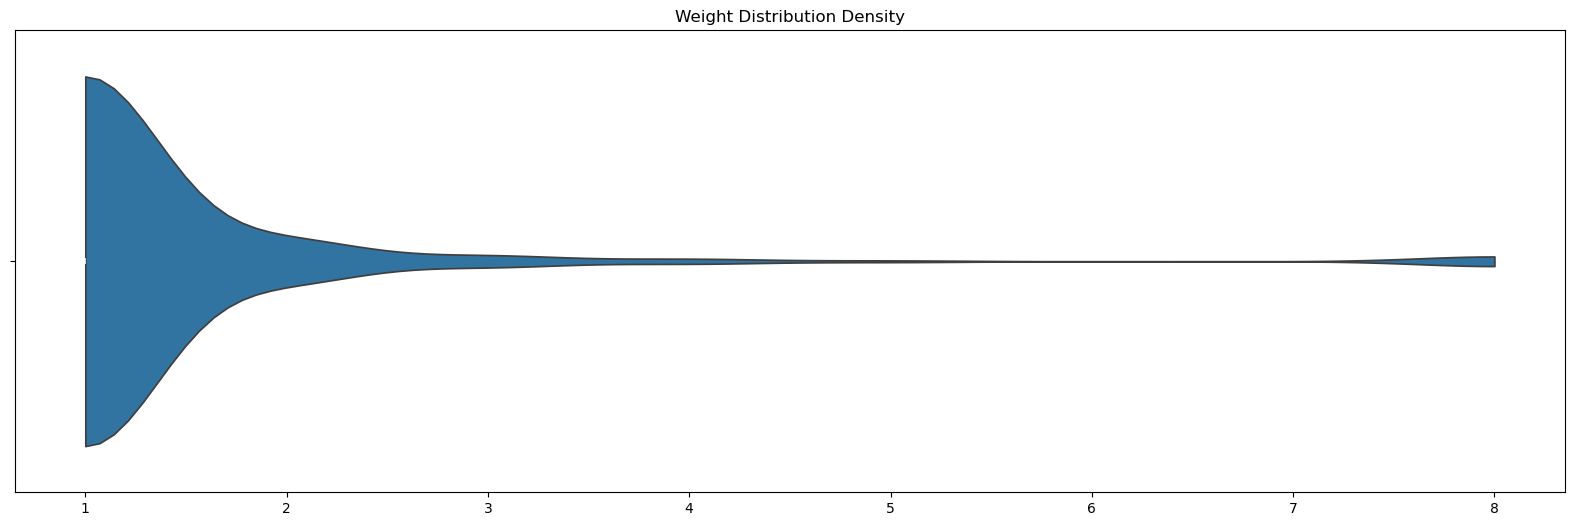

In [61]:
lw = [e[2]['integer_weight'] for e in projSG.edges.data()]
#print(lw[:3])
naf.describe_violinplot(lw, 'Weight Distribution Density')

In [62]:
edges_list = [(e[0], e[1]) for e in projSG.edges.data() if e[2]['integer_weight'] > 1]
print(edges_list[:2])
sub_pG = projSG.edge_subgraph(edges_list).copy()
naf.basic_graph_properties(sub_pG)

[('83', '69'), ('81', '66')]
{'is_multigraph': False,
 'is_directed': False,
 'number_of_nodes': 45,
 'number_of_edges': 43,
 '------': '------',
 'is connected': False,
 'components': 10,
 'density': 0.043434343434343436}


In [63]:
### Print network

g = sub_pG

cmap = plt.get_cmap('Dark2') # Dark2


# Create a figure and axis
fig, ax = plt.subplots(figsize=(18,18))


node_colors= [n[1]['categories'] for n in g.nodes.data()]
node_size= [n[1]['capital']/70 for n in g.nodes.data()]
node_labels=dict([(n[0], ('-'.join((n[1]['label']).split(' ')[:5]) )) for n in g.nodes.data()])

edges_width=[e[2]['weight']*100 for e in g.edges.data()]


#pos = nx.kamada_kawai_layout(g)

k=0.07
pos=nx.spring_layout(g, k=k)

#nx.draw_networkx_nodes(g, pos, node_size=node_size, node_color=node_colors, cmap=plt.get_cmap('Dark2'), alpha=0.4)

# Create the ellipses
for node in g.nodes():
    width = g.nodes[node]['capital']/200000
    height = g.nodes[node]['norm_degree']/30
    x, y = pos[node]
    degree = g.degree(node)
    color = cmap(degree)
    ellipse = patches.Ellipse((x, y), width, height, alpha=0.5, facecolor=color)
    ax.add_patch(ellipse)
    
nx.draw_networkx_labels(g, pos, labels=node_labels, font_size=5)

## no need to draw edges to see the structure of the graph
nx.draw_networkx_edges(g, pos,  width=edges_width, alpha=0.3)

plt.title('m-slice companies (size proportional to capital and normalized degree, color: categories)')

### cf. SVG picture
plt.savefig('images/m-sliced_companies_scotland.svg')
plt.close()

In [64]:
nodes_df[nodes_df.norm_degree > 2]\
   .sort_values(by='betweenness', ascending=False)

,id,label,bipartite,eigenvector,betweenness,members,degree,norm_degree,categories,capital
44,33,3/33—irrawaddy flotilla,0,0.000341,0.060258,4,12,3.0,3,850
57,11,1/11—united collieries,0,0.080492,0.059382,3,7,2.333333,1,1850
10,71,5/71—clydesdale bank,0,0.000158,0.048321,6,17,2.833333,5,490
77,79,"3/79—general accident, fire & life ass.",0,0.080218,0.045563,2,5,2.5,3,360
49,53,5/53—young's paraffin ligth & mineral oil,0,0.00014,0.036797,5,14,2.8,5,600
75,58,1/58—lothian coal,0,0.000083,0.034421,3,10,3.333333,1,600
47,4,5/4—j. & p. coats,0,0.000089,0.029377,4,11,2.75,5,10000
61,17,2/17—tharsis sulphur & copper,0,0.000147,0.026746,5,13,2.6,2,1389
39,95,7/95—edinburgh investment trust,0,0.000019,0.024412,4,9,2.25,7,13138
72,88,6/88—british investment trust,0,0.000049,0.023071,4,9,2.25,6,13606


### Louvain Method modularity detection

Documentation: https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.louvain.louvain_communities.html

In [77]:
l_communities = list(nx.community.louvain_communities(projSG))
print( len(l_communities), l_communities)

6 [{'99', '88', '75', '101', '100', '96', '73', '105', '65'}, {'16', '63', '23', '1', '6', '103', '104', '14', '7', '50', '93'}, {'35', '20', '56', '17', '29', '46', '76', '33', '45', '2', '27', '4', '9', '53', '62', '51', '30', '38', '39', '71', '58', '15', '94'}, {'90', '83', '95', '106', '77', '84', '89', '98', '69', '3', '85', '102', '92', '12', '80', '91'}, {'10', '86', '36', '48', '64', '79', '26', '19', '8', '24', '11'}, {'67', '70', '87', '81', '78', '59', '55', '74', '68', '66', '31', '82', '61', '28', '21', '108'}]


In [ ]:
llp = nx.community.louvain_partitions(projSG)
pprint.pprint(list(llp))

In [78]:
# communities = list(nx.community.greedy_modularity_communities(projSG))
# print( len(communities), communities)

In [79]:
# Create a dictionary to map community IDs to colors
colors = ['red',  'blue', 'yellow','brown', 'grey', 'green']
color_map = {i: colors[i % len(colors)] for i in range(len(l_communities))}

# Create a dictionary to map nodes to community IDs
node_colors = {}
for i, community in enumerate(l_communities):
    for node in community:
        node_colors[node] = color_map[i]

In [80]:
print(list(node_colors.items()))

[('99', 'red'), ('88', 'red'), ('75', 'red'), ('101', 'red'), ('100', 'red'), ('96', 'red'), ('73', 'red'), ('105', 'red'), ('65', 'red'), ('16', 'blue'), ('63', 'blue'), ('23', 'blue'), ('1', 'blue'), ('6', 'blue'), ('103', 'blue'), ('104', 'blue'), ('14', 'blue'), ('7', 'blue'), ('50', 'blue'), ('93', 'blue'), ('35', 'yellow'), ('20', 'yellow'), ('56', 'yellow'), ('17', 'yellow'), ('29', 'yellow'), ('46', 'yellow'), ('76', 'yellow'), ('33', 'yellow'), ('45', 'yellow'), ('2', 'yellow'), ('27', 'yellow'), ('4', 'yellow'), ('9', 'yellow'), ('53', 'yellow'), ('62', 'yellow'), ('51', 'yellow'), ('30', 'yellow'), ('38', 'yellow'), ('39', 'yellow'), ('71', 'yellow'), ('58', 'yellow'), ('15', 'yellow'), ('94', 'yellow'), ('90', 'brown'), ('83', 'brown'), ('95', 'brown'), ('106', 'brown'), ('77', 'brown'), ('84', 'brown'), ('89', 'brown'), ('98', 'brown'), ('69', 'brown'), ('3', 'brown'), ('85', 'brown'), ('102', 'brown'), ('92', 'brown'), ('12', 'brown'), ('80', 'brown'), ('91', 'brown'), ('

In [81]:
print(list(communities[3]))

['10', '86', '36', '48', '64', '19', '26', '79', '8', '24', '11']


In [82]:
### Print network


node_colors= [e[1] for e in list(node_colors.items())]
node_size= [n[1]['capital']/70 for n in projSG.nodes.data()]
node_labels=dict([(n[0], ('-'.join((n[1]['label']).split(' ')[:5]) )) for n in projSG.nodes.data()])

edges_width=[e[2]['weight']*100 for e in projSG.edges.data()]

plt.figure(figsize = (12,12))

pos = nx.kamada_kawai_layout(projSG)

k=0.4
#pos=nx.spring_layout(projSG, k=k)

## , cmap=plt.get_cmap('Dark2')
nx.draw_networkx_nodes(projSG, pos, node_size=node_size, node_color=node_colors, alpha=0.4)
nx.draw_networkx_labels(projSG, pos, labels=node_labels, font_size=5)

## no need to draw edges to see the structure of the graph
nx.draw_networkx_edges(projSG, pos,  width=edges_width, alpha=0.2)

plt.title('Clustered Companies (size proportional to capital, color: communities)')

### cf. SVG picture
plt.savefig('images/communitites_companies_scotland.svg')
plt.close()

In [73]:
nodes_df[nodes_df.id.isin(l_communities[3]) ]\
   .sort_values(by='capital', ascending=False)

,id,label,bipartite,eigenvector,betweenness,members,degree,norm_degree,categories,capital
15,2,2/2—caledonian railway,0,0.000397,0.166088,13,26,2.0,2,42899
27,94,7/94—australasian mortgage & agency,0,0.000006,0.0,1,1,1.0,7,16351
47,4,5/4—j. & p. coats,0,0.000089,0.029377,4,11,2.75,5,10000
19,9,5/9—linen thread,0,0.000007,0.001026,2,2,1.0,5,2000
45,10,5/10—burmah oil,0,0.003269,0.017714,2,2,1.0,5,1991
67,15,5/15—lanarkshire & dumbartonshire railway,0,0.000078,0.008677,3,8,2.666667,5,1419
61,17,2/17—tharsis sulphur & copper,0,0.000147,0.026746,5,13,2.6,2,1389
36,20,1/20—william mcewan,0,0.000025,0.0,1,2,2.0,1,1250
46,27,4/27—coltness iron,0,0.000092,0.001069,2,8,4.0,4,934
63,29,5/29—callander & oban railway,0,0.000294,0.017746,5,11,2.2,5,910
